In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
from modules.datasets import ICBHIFeaturesDataset, KAUHFeaturesDataset, CombinedFeaturesDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [ ]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [3]:
extractor = "MagSTFT"

icbhi_dataset = ICBHIFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"ICBHI size: {len(icbhi_dataset)} samples")
display(icbhi_dataset.data.head(5))

kauh_dataset = KAUHFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"KAUH size: {len(kauh_dataset)} samples")
display(kauh_dataset.data.head(5))

combined_dataset = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
print(f"Combined size: {len(combined_dataset)} samples")
display(combined_dataset.data.head(5))

ICBHI size: 3893 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label
0,ICBHI,101_1b1_Al_sc_Meditron_clip-000-005.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
1,ICBHI,101_1b1_Al_sc_Meditron_clip-005-010.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
2,ICBHI,101_1b1_Al_sc_Meditron_clip-010-015.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
3,ICBHI,101_1b1_Al_sc_Meditron_clip-015-020.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7
4,ICBHI,101_1b1_Pr_sc_Meditron_clip-000-005.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7


KAUH size: 763 samples


,Source,FileName,Diagnosis,FilterCode,PatientId,Sound type,ChestLocation,Age,Sex,Label
0,KAUH,"BP100_N,N,P R M,70,F_clip-000-005.npz",Healthy,B,P100,N,P R M,70.0,F_clip-000-005,4
1,KAUH,"BP100_N,N,P R M,70,F_clip-005-010.npz",Healthy,B,P100,N,P R M,70.0,F_clip-005-010,4
2,KAUH,"BP101_Asthma,E W,P L M,12,F_clip-000-005.npz",Asthma,B,P101,E W,P L M,12.0,F_clip-000-005,0
3,KAUH,"BP101_Asthma,E W,P L M,12,F_clip-005-010.npz",Asthma,B,P101,E W,P L M,12.0,F_clip-005-010,0
4,KAUH,"BP102_N,N,P L L,41,M_clip-000-005.npz",Healthy,B,P102,N,P L L,41.0,M_clip-000-005,4


Combined size: 4656 samples


,Source,FileName,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label,FilterCode,Sound type
0,ICBHI,101_1b1_Al_sc_Meditron_clip-000-005.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,NaN,NaN
1,ICBHI,101_1b1_Al_sc_Meditron_clip-005-010.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,NaN,NaN
2,ICBHI,101_1b1_Al_sc_Meditron_clip-010-015.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,NaN,NaN
3,ICBHI,101_1b1_Al_sc_Meditron_clip-015-020.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,7,NaN,NaN
4,ICBHI,101_1b1_Pr_sc_Meditron_clip-000-005.npz,URTI,3.0,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,7,NaN,NaN


Diagnosis
COPD              3487
Healthy            448
Asthma             283
Pneumonia          199
URTI                90
Bronchiectasis      64
Bronchiolitis       52
Lung Fibrosis       33
dtype: int64

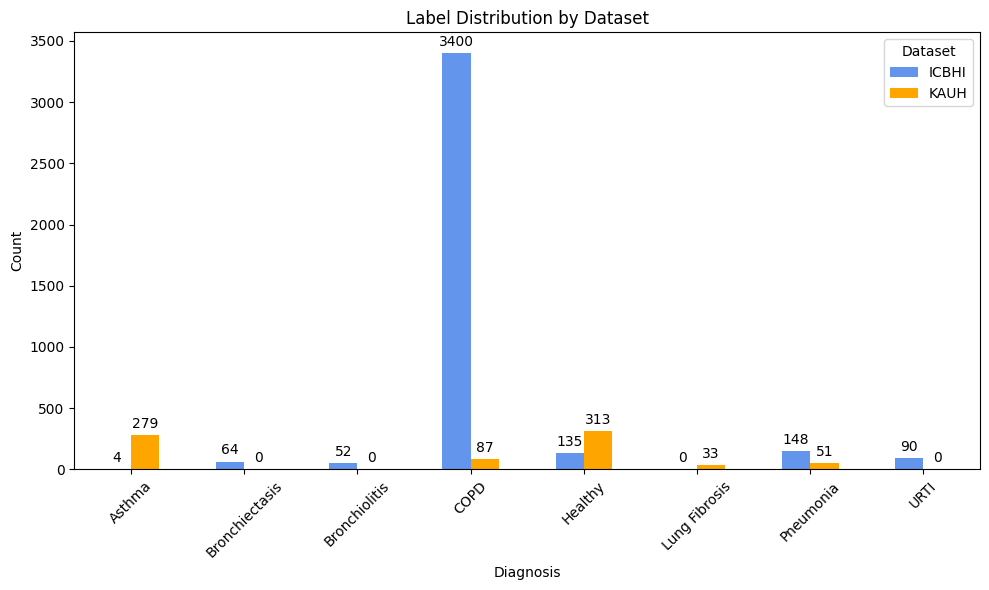

Diagnosis
Asthma            33
Bronchiectasis     7
Bronchiolitis      6
COPD              73
Healthy           61
Lung Fibrosis      4
Pneumonia         11
URTI              14
Name: PatientId, dtype: int64


In [4]:
counts_df = (
    combined_dataset.data
    .groupby(["Diagnosis", "Source"])
    .size()
    .unstack(fill_value=0)
)
label_counts = counts_df.sum(axis=1).sort_values(ascending=False)
display(label_counts)

colors = ["cornflowerblue", "orange"]
ax = counts_df.plot(kind="bar", figsize=(10, 6), color=colors)
ax.set_title("Label Distribution by Dataset")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Dataset")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

print(combined_dataset.data.groupby("Diagnosis")["PatientId"].nunique())

Sample 0:
  File name: 113_1b1_Pr_sc_Litt3200_clip-015-020.npz
  Label: 3 (COPD)
  Sample rate: 22050
  Feature extractor: MagSTFT
  Feature shape: (1025, 216)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 0.000


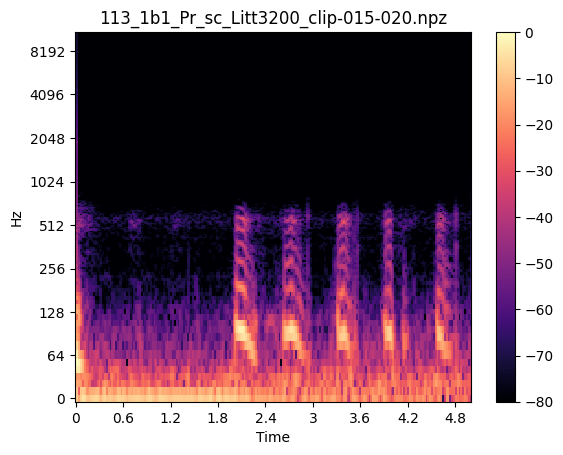

In [6]:
combined_dataset.unit_test(idx=0)

## Other Features

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Sample rate: 22050
  Feature extractor: MelSpectrogram
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: -80.000
  Feature max value: 0.000


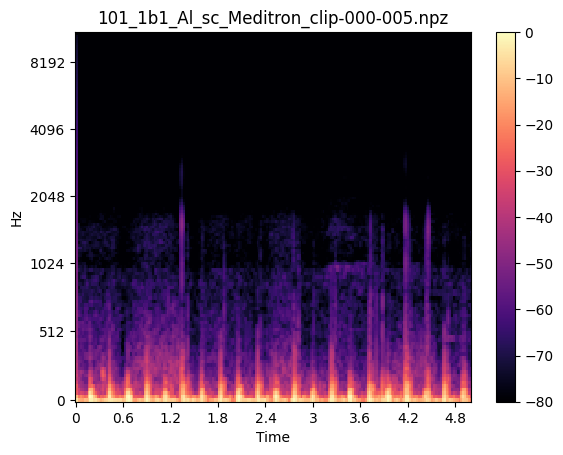

In [7]:
extractor = "MelSpectrogram"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Sample rate: 22050
  Feature extractor: MFCC
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: -480.105
  Feature max value: 193.862


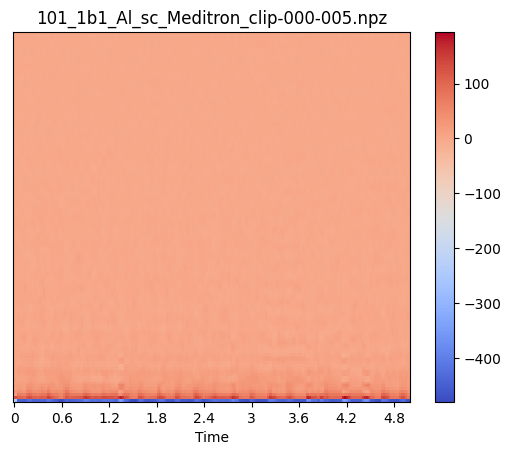

In [8]:
extractor = "MFCC"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Sample rate: 22050
  Feature extractor: Chroma
  Feature shape: (128, 216)
  Feature dtype: float32
  Feature min value: 0.312
  Feature max value: 1.000


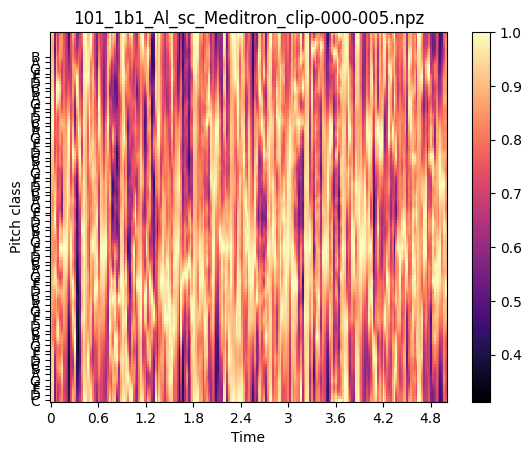

In [9]:
extractor = "Chroma"
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_clip-000-005.npz
  Label: 7 (URTI)
  Sample rate: 22050
  Feature extractor: ['MelSpectrogram', 'MFCC', 'Chroma']
  Feature shape: (128, 216, 3)
  Feature dtype: float32
  Feature min value: -480.105
  Feature max value: 193.862


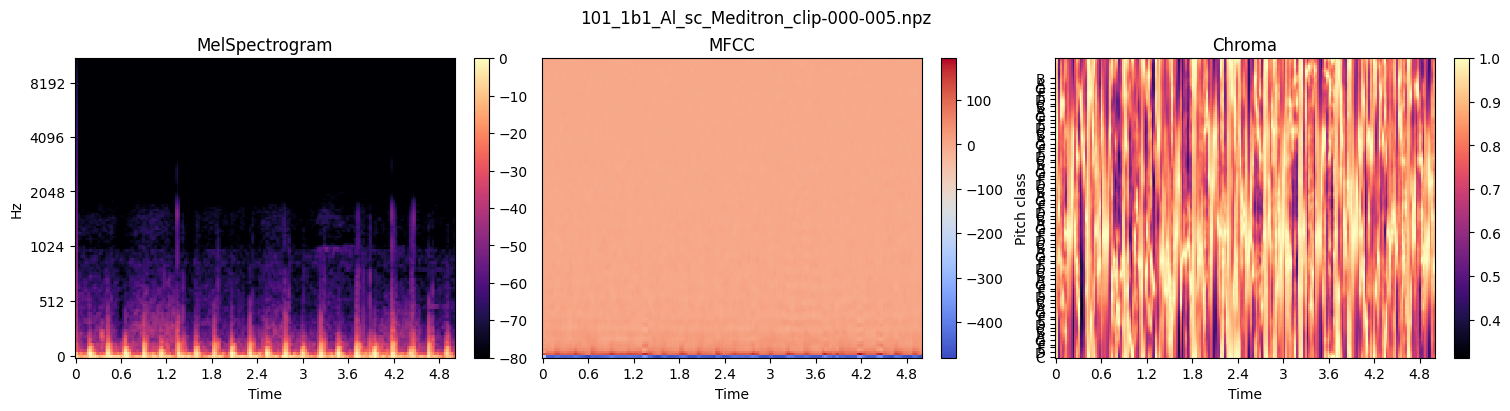

In [10]:
extractor = ["MelSpectrogram", "MFCC", "Chroma"]
combined = CombinedFeaturesDataset(DATA_FOLDER, "all", feature_extractor=extractor, classes=SELECTED_CLASSES, random_seed=SEED)
combined.unit_test(idx=0)